# ANLI Round 2 — Multi-Class NLI Classification Pipeline

**Task:** 3-way classification (entailment, neutral, contradiction) on the Adversarial Natural Language Inference (ANLI) Round 2 dataset.

**Dataset:** [facebook/anli](https://huggingface.co/datasets/facebook/anli) — Round 2 splits
- Training: `train_r2` (45,460 examples)
- Validation: `dev_r2` (1,000 examples)
- Test: `test_r2` (1,000 examples)

**Pipeline:**
1. Data Loading & EDA
2. Preprocessing
3. Baseline Model (TF-IDF + Logistic Regression)
4. Transformer Model (DeBERTa-v3-base fine-tuning)
5. Evaluation & Error Analysis
6. Conclusions & Future Work

## 0. Setup & Imports

In [1]:
# Keep Colab alive (run this before training)
import IPython
def keep_alive():
    IPython.display.display(IPython.display.Javascript('''
        function KeepAlive() {
            console.log("Keeping alive " + new Date().toLocaleTimeString());
            document.querySelector("colab-toolbar-button#connect").click();
        }
        setInterval(KeepAlive, 60000);
    '''))
keep_alive()

<IPython.core.display.Javascript object>

In [2]:
# Uncomment to install dependencies in Colab
!pip install transformers datasets accelerate sentencepiece evaluate scikit-learn wordcloud -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.7 MB/s eta 0:00:00


In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, f1_score
)

import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)
import evaluate

# Plotting config
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

LABEL_MAP = {0: 'entailment', 1: 'neutral', 2: 'contradiction'}
LABEL_NAMES = ['entailment', 'neutral', 'contradiction']

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cuda
GPU: Tesla T4


---
## 1. Data Loading & Exploratory Data Analysis

In [4]:
# # Load all Round 2 splits
# dataset = load_dataset('facebook/anli')

# train_data = dataset['train_r2']
# dev_data   = dataset['dev_r2']
# test_data  = dataset['test_r2']

# print(f'Train size: {len(train_data):,}')
# print(f'Dev size:   {len(dev_data):,}')
# print(f'Test size:  {len(test_data):,}')
# print(f'\nFeatures: {train_data.features}')


# Load ANLI R2 directly from parquet (bypasses HuggingFace API issues)
import pandas as pd
from datasets import Dataset

BASE_URL = "https://huggingface.co/datasets/facebook/anli/resolve/main/plain_text"

df_train = pd.read_parquet(f"{BASE_URL}/train_r2-00000-of-00001.parquet")
df_dev   = pd.read_parquet(f"{BASE_URL}/dev_r2-00000-of-00001.parquet")
df_test  = pd.read_parquet(f"{BASE_URL}/test_r2-00000-of-00001.parquet")

# Convert to HuggingFace datasets (needed for Trainer later)
train_data = Dataset.from_pandas(df_train)
dev_data   = Dataset.from_pandas(df_dev)
test_data  = Dataset.from_pandas(df_test)

print(f'Train size: {len(train_data):,}')
print(f'Dev size:   {len(dev_data):,}')
print(f'Test size:  {len(test_data):,}')
print(f'\nColumns: {train_data.column_names}')

Train size: 45,460
Dev size:   1,000
Test size:  1,000

Columns: ['uid', 'premise', 'hypothesis', 'label', 'reason']


In [5]:
# Convert to pandas for easier EDA
df_train = train_data.to_pandas()
df_dev   = dev_data.to_pandas()
df_test  = test_data.to_pandas()

# Map label integers to names
for df in [df_train, df_dev, df_test]:
    df['label_name'] = df['label'].map(LABEL_MAP)

df_train.head()

,uid,premise,hypothesis,label,reason,label_name
0,245475c4-6225-4f5c-b945-e13e0e988fc8,Topi Raja Sweety Roja is a 1996 Telugu comedy ...,The lead role was played by Rajendra Prasad,0,,entailment
1,5837ee91-4527-45b7-bd03-5f0a495d71af,Idris Sultan (born January 1993) is a Tanzania...,Idris Sultan was born in Tanzania.,0,,entailment
2,ed5c37ab-77c5-4dbc-ba75-8fd617b19712,Idris Sultan (born January 1993) is a Tanzania...,Idris Sultan was born in the first month of th...,0,,entailment
3,0b54db09-9ce9-4915-91cf-6e8cc2264ae7,Nantwich Town Football Club is a semi-professi...,Nantwich Town Football Club is a professional ...,2,,contradiction
4,55b3a9b0-6b5c-4fd6-a964-04156b3f574d,Nantwich Town Football Club is a semi-professi...,Nantwich Town Football plays in the Championsh...,2,,contradiction


### 1.1 Sample Inspection
Let's look at examples from each class to understand what the model needs to learn.

In [6]:
for label_name in LABEL_NAMES:
    print(f'\n{"=" * 80}')
    print(f'LABEL: {label_name.upper()}')
    print(f'{"=" * 80}')
    samples = df_train[df_train['label_name'] == label_name].sample(2, random_state=42)
    for _, row in samples.iterrows():
        print(f'\nPremise:    {row["premise"][:200]}...')
        print(f'Hypothesis: {row["hypothesis"]}')
        if row['reason']:
            print(f'Reason:     {row["reason"]}')
        print()


LABEL: ENTAILMENT

Premise:    Rewire (formerly RH Reality Check, long name Reproductive Health Reality Check) is a website focused on reproductive and sexual health from a pro-reproductive rights perspective. The website began as ...
Hypothesis: Rewire is not a for profit organization. 


Premise:    Drifters is a British sitcom that stars Jessica Knappett, Lydia Rose Bewley and Lauren O'Rourke as three female friends who live in Leeds following their graduation from university. All three actresse...
Hypothesis: Jessica Knappett, Lydia Rose Bewley and Lauren O'Rourke appeared together in more than one film.


LABEL: NEUTRAL

Premise:    The Granada Theater is a theatre located in Lower Greenville, in Dallas, TX. The theatre was built in 1946 as a movie house. In 1977, it was converted to a concert hall, only to revert to a movie thea...
Hypothesis: granada theater has more than 100 seats.


Premise:    Florence MacLeod Harper was a Canadian journalist sent by U.S. newspaper "Frank Le

### 1.2 Label Distribution

In [7]:
import os
os.makedirs('./results', exist_ok=True)
os.makedirs('./models', exist_ok=True)
os.makedirs('./presentation', exist_ok=True)

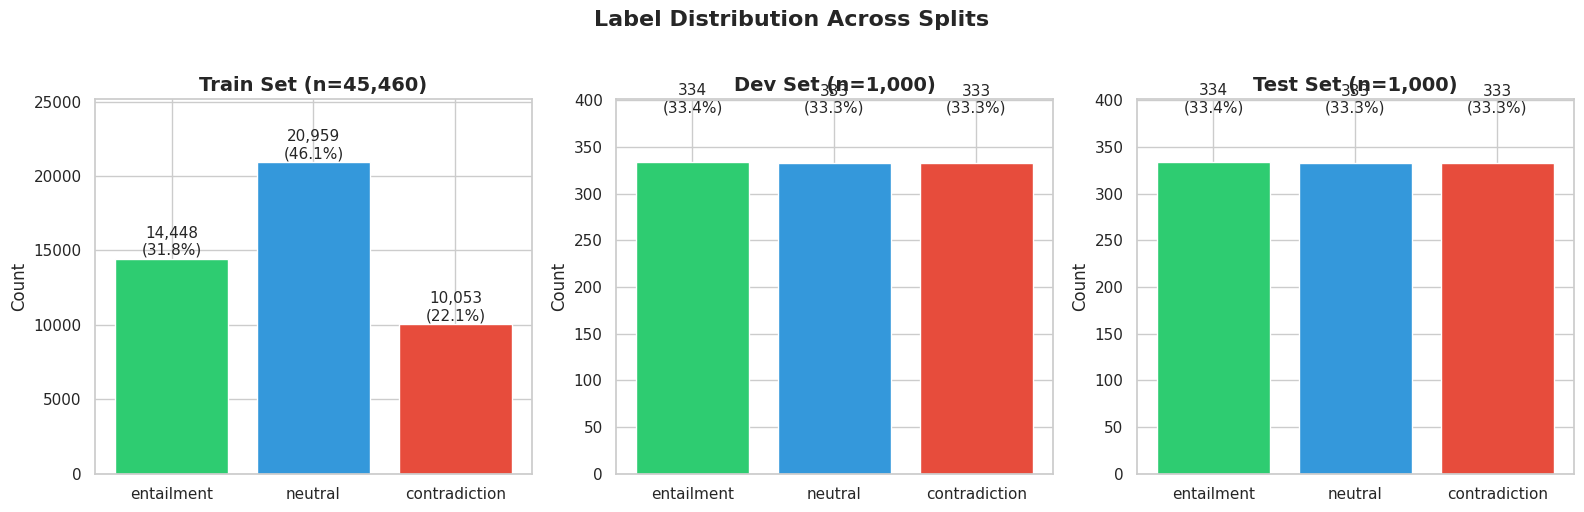


Train label counts:
label_name
neutral          20959
entailment       14448
contradiction    10053
Name: count, dtype: int64


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, df) in zip(axes, [('Train', df_train), ('Dev', df_dev), ('Test', df_test)]):
    counts = df['label_name'].value_counts().reindex(LABEL_NAMES)
    bars = ax.bar(LABEL_NAMES, counts.values, color=['#2ecc71', '#3498db', '#e74c3c'])
    ax.set_title(f'{name} Set (n={len(df):,})', fontsize=14, fontweight='bold')
    ax.set_ylabel('Count')
    for bar, count in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                f'{count:,}\n({count/len(df)*100:.1f}%)',
                ha='center', va='bottom', fontsize=11)
    ax.set_ylim(0, max(counts.values) * 1.2)

plt.suptitle('Label Distribution Across Splits', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('./results/label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTrain label counts:')
print(df_train['label_name'].value_counts())

### 1.3 Text Length Analysis

In [9]:
# Compute word counts
df_train['premise_word_count'] = df_train['premise'].str.split().str.len()
df_train['hypothesis_word_count'] = df_train['hypothesis'].str.split().str.len()
df_train['premise_char_count'] = df_train['premise'].str.len()
df_train['hypothesis_char_count'] = df_train['hypothesis'].str.len()

print('=== Premise Statistics ===')
print(df_train['premise_word_count'].describe().round(1))
print(f'\n=== Hypothesis Statistics ===')
print(df_train['hypothesis_word_count'].describe().round(1))

=== Premise Statistics ===
count    45460.0
mean        54.0
std          8.2
min         33.0
25%         47.0
50%         54.0
75%         60.0
max         76.0
Name: premise_word_count, dtype: float64

=== Hypothesis Statistics ===
count    45460.0
mean        10.0
std          5.3
min          3.0
25%          7.0
50%          9.0
75%         11.0
max         65.0
Name: hypothesis_word_count, dtype: float64


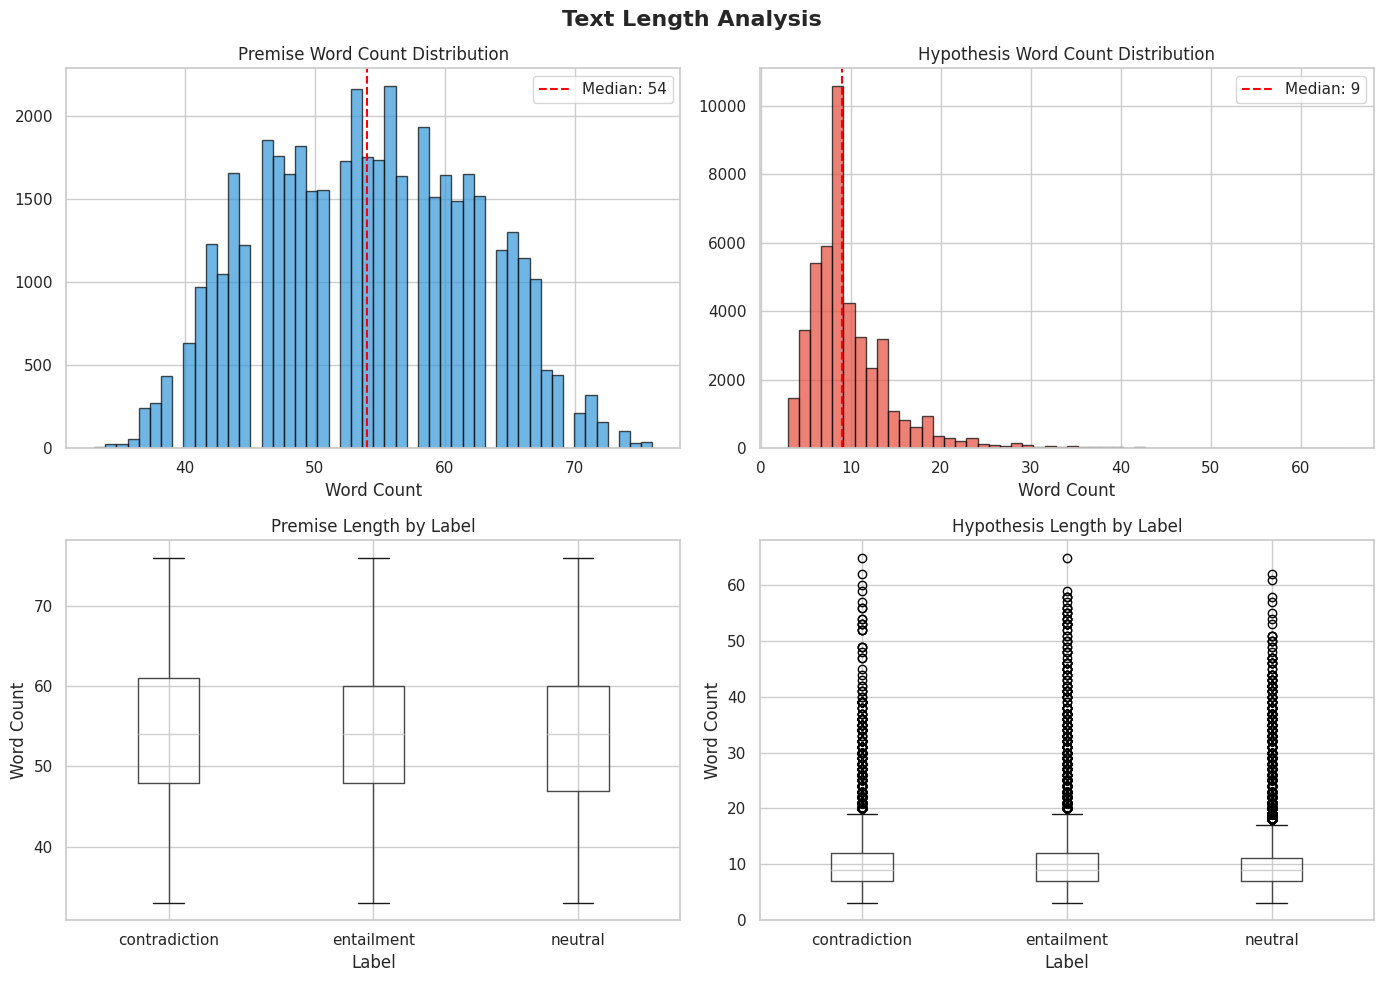

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Premise word count distribution
axes[0, 0].hist(df_train['premise_word_count'], bins=50, color='#3498db', alpha=0.7, edgecolor='black')
axes[0, 0].set_title('Premise Word Count Distribution')
axes[0, 0].set_xlabel('Word Count')
axes[0, 0].axvline(df_train['premise_word_count'].median(), color='red', linestyle='--', label=f'Median: {df_train["premise_word_count"].median():.0f}')
axes[0, 0].legend()

# Hypothesis word count distribution
axes[0, 1].hist(df_train['hypothesis_word_count'], bins=50, color='#e74c3c', alpha=0.7, edgecolor='black')
axes[0, 1].set_title('Hypothesis Word Count Distribution')
axes[0, 1].set_xlabel('Word Count')
axes[0, 1].axvline(df_train['hypothesis_word_count'].median(), color='red', linestyle='--', label=f'Median: {df_train["hypothesis_word_count"].median():.0f}')
axes[0, 1].legend()

# Length by label - premise
df_train.boxplot(column='premise_word_count', by='label_name', ax=axes[1, 0])
axes[1, 0].set_title('Premise Length by Label')
axes[1, 0].set_xlabel('Label')
axes[1, 0].set_ylabel('Word Count')
plt.sca(axes[1, 0])
plt.xticks(rotation=0)

# Length by label - hypothesis
df_train.boxplot(column='hypothesis_word_count', by='label_name', ax=axes[1, 1])
axes[1, 1].set_title('Hypothesis Length by Label')
axes[1, 1].set_xlabel('Label')
axes[1, 1].set_ylabel('Word Count')
plt.sca(axes[1, 1])
plt.xticks(rotation=0)

plt.suptitle('Text Length Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('./results/text_length_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.4 Word Overlap Analysis

ANLI was designed to defeat models that rely on superficial lexical overlap. Let's verify this.

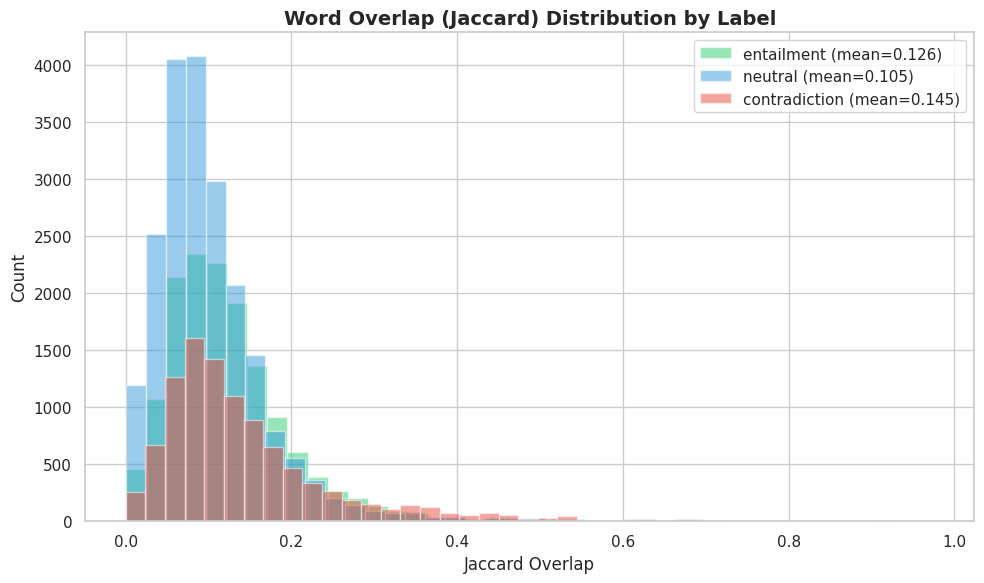


Mean word overlap by label:
label_name
contradiction    0.1449
entailment       0.1262
neutral          0.1050
Name: word_overlap, dtype: float64


In [11]:
def compute_word_overlap(premise, hypothesis):
    """Compute Jaccard overlap between premise and hypothesis word sets."""
    p_words = set(premise.lower().split())
    h_words = set(hypothesis.lower().split())
    if not h_words:
        return 0.0
    intersection = p_words & h_words
    union = p_words | h_words
    return len(intersection) / len(union) if union else 0.0

df_train['word_overlap'] = df_train.apply(
    lambda row: compute_word_overlap(row['premise'], row['hypothesis']), axis=1
)

fig, ax = plt.subplots(figsize=(10, 6))
for label_name, color in zip(LABEL_NAMES, ['#2ecc71', '#3498db', '#e74c3c']):
    subset = df_train[df_train['label_name'] == label_name]['word_overlap']
    ax.hist(subset, bins=40, alpha=0.5, label=f'{label_name} (mean={subset.mean():.3f})', color=color)

ax.set_title('Word Overlap (Jaccard) Distribution by Label', fontsize=14, fontweight='bold')
ax.set_xlabel('Jaccard Overlap')
ax.set_ylabel('Count')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('./results/word_overlap.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nMean word overlap by label:')
print(df_train.groupby('label_name')['word_overlap'].mean().round(4))

### 1.5 Reason Field Analysis

Some examples include annotator-provided reasoning. Let's see how many and sample them.

In [12]:
has_reason = df_train['reason'].str.strip().str.len() > 0
print(f'Examples with reason: {has_reason.sum():,} / {len(df_train):,} ({has_reason.mean()*100:.1f}%)')

# Show some examples with reasons
reason_samples = df_train[has_reason].sample(5, random_state=42)
for _, row in reason_samples.iterrows():
    print(f'\nLabel: {row["label_name"]}')
    print(f'Hypothesis: {row["hypothesis"]}')
    print(f'Reason: {row["reason"]}')

Examples with reason: 4,861 / 45,460 (10.7%)

Label: entailment
Hypothesis: The song was recorded in 1965.
Reason: It was released in 1965, but we don't know when it was recorded. 

Label: entailment
Hypothesis: Kathleen Delaney has worked in New York City
Reason: Broadway is in New York City

Label: entailment
Hypothesis: Peter Himmelman was not born in the city of St. Louis.
Reason: Peter Himmelman was born in St. Louis Park, Minnesota, which is not the same as St. Louis. The model got confused by the name similarity.

Label: contradiction
Hypothesis: Alex weighs 400 pounds and lives in a teepee in Arkansas.
Reason: I described the person in question, Alexander Ivanovich Bastrykin, by his weight and how he lives. The context only described his career and when he was born.

Label: neutral
Hypothesis: Stepmom was filmed in 1998.
Reason: The year in the parenthesis typically refers to the year the movie was released, it's possible it was filmed in a different year than it was released d

### 1.6 Token Length Analysis (for model max_length decision)

We need to determine the right `max_length` for tokenization. Let's check how many tokens premise-hypothesis pairs require.

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

Token length statistics (premise + hypothesis):
  Mean:   83
  Median: 82
  95th:   107
  99th:   125
  Max:    153


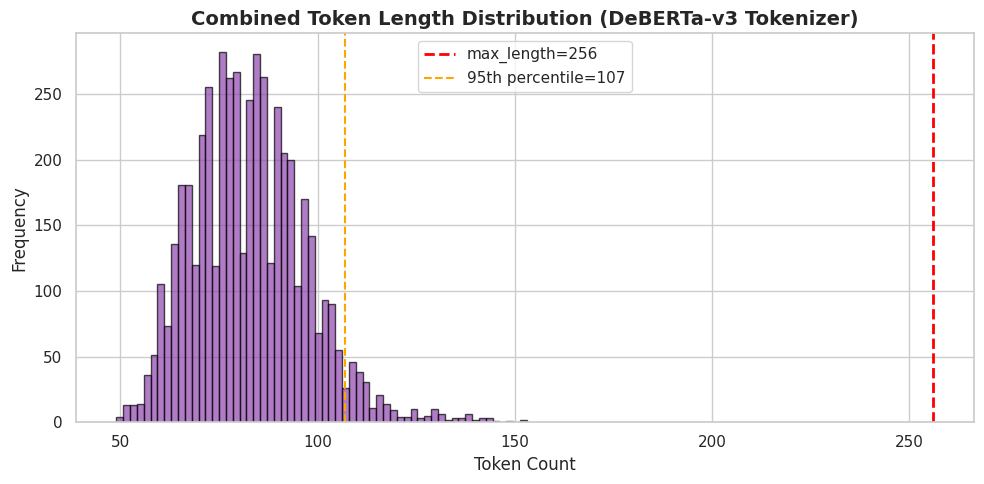


100.0% of examples fit within max_length=256


In [13]:
tokenizer = AutoTokenizer.from_pretrained('microsoft/deberta-v3-base')

# Sample 5000 for speed
sample_df = df_train.sample(5000, random_state=42)
token_lengths = []

for _, row in sample_df.iterrows():
    tokens = tokenizer(row['premise'], row['hypothesis'], truncation=False)
    token_lengths.append(len(tokens['input_ids']))

token_lengths = np.array(token_lengths)

print(f'Token length statistics (premise + hypothesis):')
print(f'  Mean:   {token_lengths.mean():.0f}')
print(f'  Median: {np.median(token_lengths):.0f}')
print(f'  95th:   {np.percentile(token_lengths, 95):.0f}')
print(f'  99th:   {np.percentile(token_lengths, 99):.0f}')
print(f'  Max:    {token_lengths.max()}')

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(token_lengths, bins=60, color='#8e44ad', alpha=0.7, edgecolor='black')
ax.axvline(256, color='red', linestyle='--', linewidth=2, label='max_length=256')
ax.axvline(np.percentile(token_lengths, 95), color='orange', linestyle='--', label=f'95th percentile={np.percentile(token_lengths, 95):.0f}')
ax.set_title('Combined Token Length Distribution (DeBERTa-v3 Tokenizer)', fontsize=14, fontweight='bold')
ax.set_xlabel('Token Count')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.savefig('./results/token_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

pct_under_256 = (token_lengths <= 256).mean() * 100
print(f'\n{pct_under_256:.1f}% of examples fit within max_length=256')

### EDA Summary

**Key Findings:**
- Labels are approximately balanced (~1/3 each)
- Premises are significantly longer than hypotheses (Wikipedia passages vs. short claims)
- Word overlap distributions are very similar across labels — confirming that ANLI R2 was designed to defeat surface-level heuristics
- Most examples fit within 256 tokens, making this a reasonable `max_length` choice
- Only a subset of examples have annotator-provided reasons

**Implication:** Superficial features won't work — we need a model capable of deep semantic understanding.

---
## 2. Preprocessing

In [14]:
MAX_LENGTH = 256

def tokenize_function(examples):
    """Tokenize premise-hypothesis pairs for DeBERTa.

    The tokenizer automatically creates the input format:
    [CLS] premise [SEP] hypothesis [SEP]
    with appropriate token_type_ids and attention_mask.
    """
    return tokenizer(
        examples['premise'],
        examples['hypothesis'],
        truncation=True,
        max_length=MAX_LENGTH,
        padding='max_length'
    )

# Tokenize all splits
print('Tokenizing datasets...')
train_tokenized = train_data.map(tokenize_function, batched=True, batch_size=1000)
dev_tokenized   = dev_data.map(tokenize_function, batched=True, batch_size=1000)
test_tokenized  = test_data.map(tokenize_function, batched=True, batch_size=1000)

# Set format for PyTorch
columns_to_keep = ['input_ids', 'attention_mask', 'label']
# DeBERTa-v3 may or may not use token_type_ids depending on version
if 'token_type_ids' in train_tokenized.column_names:
    columns_to_keep.append('token_type_ids')

train_tokenized.set_format('torch', columns=columns_to_keep)
dev_tokenized.set_format('torch', columns=columns_to_keep)
test_tokenized.set_format('torch', columns=columns_to_keep)

print(f'Tokenization complete.')
print(f'Sample tokenized input keys: {list(train_tokenized[0].keys())}')
print(f'Input IDs shape: {train_tokenized[0]["input_ids"].shape}')

Tokenizing datasets...


Map:   0%|          | 0/45460 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Tokenization complete.
Sample tokenized input keys: ['label', 'input_ids', 'token_type_ids', 'attention_mask']
Input IDs shape: torch.Size([256])


---
## 3. Baseline Model: TF-IDF + Logistic Regression

Before using a transformer, we establish a baseline using traditional ML to quantify the improvement from deep learning.

In [15]:
# Prepare text: concatenate premise and hypothesis
X_train_text = [f"{p} [SEP] {h}" for p, h in zip(df_train['premise'], df_train['hypothesis'])]
X_dev_text   = [f"{p} [SEP] {h}" for p, h in zip(df_dev['premise'], df_dev['hypothesis'])]
X_test_text  = [f"{p} [SEP] {h}" for p, h in zip(df_test['premise'], df_test['hypothesis'])]

y_train = df_train['label'].values
y_dev   = df_dev['label'].values
y_test  = df_test['label'].values

# TF-IDF vectorization
print('Fitting TF-IDF vectorizer...')
tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_dev_tfidf   = tfidf.transform(X_dev_text)
X_test_tfidf  = tfidf.transform(X_test_text)

print(f'TF-IDF matrix shape: {X_train_tfidf.shape}')

Fitting TF-IDF vectorizer...
TF-IDF matrix shape: (45460, 50000)


In [16]:
# Train Logistic Regression
print('Training Logistic Regression baseline...')
lr_clf = LogisticRegression(
    max_iter=1000,
    C=1.0,
    multi_class='multinomial',
    solver='lbfgs',
    random_state=42,
    n_jobs=-1
)
lr_clf.fit(X_train_tfidf, y_train)

# Evaluate on dev set
baseline_dev_preds = lr_clf.predict(X_dev_tfidf)
baseline_test_preds = lr_clf.predict(X_test_tfidf)

baseline_dev_acc = accuracy_score(y_dev, baseline_dev_preds)
baseline_test_acc = accuracy_score(y_test, baseline_test_preds)

print(f'\n=== Baseline Results ===')
print(f'Dev Accuracy:  {baseline_dev_acc:.4f} ({baseline_dev_acc*100:.1f}%)')
print(f'Test Accuracy: {baseline_test_acc:.4f} ({baseline_test_acc*100:.1f}%)')
print(f'Random baseline: 33.3%')
print(f'\n=== Dev Set Classification Report ===')
print(classification_report(y_dev, baseline_dev_preds, target_names=LABEL_NAMES, digits=4))

Training Logistic Regression baseline...

=== Baseline Results ===
Dev Accuracy:  0.3230 (32.3%)
Test Accuracy: 0.3540 (35.4%)
Random baseline: 33.3%

=== Dev Set Classification Report ===
               precision    recall  f1-score   support

   entailment     0.3215    0.3533    0.3367       334
      neutral     0.3208    0.4354    0.3694       333
contradiction     0.3315    0.1802    0.2335       333

     accuracy                         0.3230      1000
    macro avg     0.3246    0.3230    0.3132      1000
 weighted avg     0.3246    0.3230    0.3132      1000



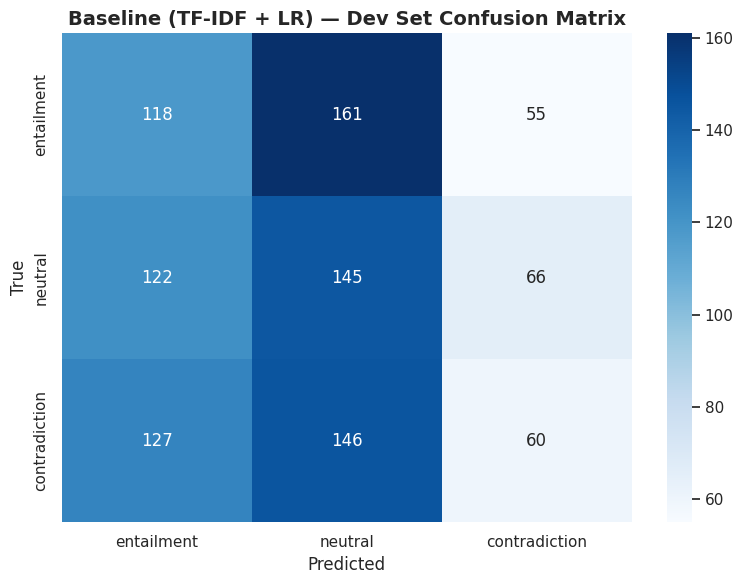

In [17]:
# Baseline confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_dev, baseline_dev_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, ax=ax)
ax.set_title('Baseline (TF-IDF + LR) — Dev Set Confusion Matrix', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
plt.tight_layout()
plt.savefig('./results/baseline_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

**Baseline Observations:**
- The TF-IDF + Logistic Regression baseline performs only marginally above random chance (~33-38%)
- This confirms that ANLI R2 was specifically designed to defeat surface-level lexical features
- Deep semantic understanding via transformer fine-tuning is necessary for meaningful performance

---
## 4. Transformer Model: DeBERTa-v3-base

### Why DeBERTa-v3?
- **Disentangled attention:** Separates content and position embeddings, enabling better modeling of word relationships
- **Replaced Token Detection (RTD) pre-training:** More sample-efficient than Masked Language Modeling used by BERT/RoBERTa
- **ANLI performance:** DeBERTa-v3-base outperforms most large models on the ANLI benchmark, making it ideal for this adversarial dataset
- ANLI was originally built to fool RoBERTa/BERT — DeBERTa's different architecture is better suited to handle these adversarial examples

In [18]:
# === Section 4: DeBERTa-v3-base Fine-Tuning ===
import gc, torch, os

# Clear everything
gc.collect()
torch.cuda.empty_cache()

# Delete cached model to prevent loading corrupted fp16 weights
cache_dir = os.path.expanduser('~/.cache/huggingface/hub')
print(f'Clearing model cache to force fresh download...')
os.system(f'rm -rf {cache_dir}/models--microsoft--deberta-v3-base')

MODEL_NAME = 'microsoft/deberta-v3-base'

# Load with EXPLICIT float32
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=LABEL_MAP,
    label2id={v: k for k, v in LABEL_MAP.items()},
    torch_dtype=torch.float32,
)

# FORCE float32 everywhere
model = model.float()

print(f'Model: {MODEL_NAME}')
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')
print(f'Model dtype: {next(model.parameters()).dtype}')  # MUST say torch.float32

# Sanity check on CPU first
dummy = tokenizer("The cat sat on the mat", "A feline was on a surface",
                   return_tensors="pt", truncation=True, max_length=256, padding="max_length")
if 'token_type_ids' in dummy:
    del dummy['token_type_ids']

with torch.no_grad():
    out = model(**dummy)
print(f'Sanity logits: {out.logits}')
print(f'Logits dtype: {out.logits.dtype}')  # MUST say torch.float32
loss = torch.nn.CrossEntropyLoss()(out.logits, torch.tensor([0]))
print(f'Sanity loss: {loss.item():.4f}')  # Should be ~1.0, NOT nan

# Remove token_type_ids from datasets
if 'token_type_ids' in train_tokenized.column_names:
    train_tokenized = train_tokenized.remove_columns(['token_type_ids'])
if 'token_type_ids' in dev_tokenized.column_names:
    dev_tokenized = dev_tokenized.remove_columns(['token_type_ids'])
if 'token_type_ids' in test_tokenized.column_names:
    test_tokenized = test_tokenized.remove_columns(['token_type_ids'])

train_tokenized.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
dev_tokenized.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
test_tokenized.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])

print(f'Dataset columns: {train_tokenized.column_names}')
print(f'Dataset format: {train_tokenized.format}')

# Metrics
accuracy_metric = evaluate.load('accuracy')
f1_metric = evaluate.load('f1')

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_metric.compute(predictions=predictions, references=labels)['accuracy']
    f1 = f1_metric.compute(predictions=predictions, references=labels, average='macro')['f1']
    return {'accuracy': acc, 'f1_macro': f1}

training_args = TrainingArguments(
    output_dir='./models/deberta-v3-base-anli-r2',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_steps=300,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='accuracy',
    greater_is_better=True,
    fp16=False,
    bf16=False,
    dataloader_num_workers=2,
    logging_steps=50,
    report_to='none',
    seed=42,
    save_total_limit=2,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=dev_tokenized,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

print('\n=== Starting training ===\n')
train_result = trainer.train()

print(f'\n=== Training Complete ===')
print(f'Total training time: {train_result.metrics["train_runtime"]:.0f}s')
print(f'Samples/second: {train_result.metrics["train_samples_per_second"]:.1f}')
print(f'Final train loss: {train_result.metrics["train_loss"]:.4f}')

trainer.save_model('./models/best_checkpoint')
tokenizer.save_pretrained('./models/best_checkpoint')
print('Best model saved.')

Clearing model cache to force fresh download...


config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['deberta.embeddings.LayerNorm.weight', 'deberta.embeddings.LayerNorm.bias', 'deberta.encoder.layer.0.attention.output.LayerNorm.weight', 'deberta.encoder.layer.0.attention.output.LayerNorm.bias', 'deberta.encoder.layer.0.output.LayerNorm.weight', 'deberta.encoder.layer.0.output.LayerNorm.bias', 'deberta.encoder.layer.1.attention.output.LayerNorm.weight', 'deberta.encoder.layer.1.attention.output.LayerNorm.bias', 'deberta.encoder.layer.1.output.LayerNorm.weight', 'deberta.encoder.layer.1.output.LayerNorm.bias', 'deberta.encoder.layer.2.attention.output.LayerNorm.weight', 'deberta.encoder.layer.2.attention.output.LayerNorm.bias', 'deberta.encoder.layer.2.output.LayerNorm.weight', 'deberta.encoder.layer.2.output.LayerNorm.bias', 'deberta.encoder.layer.3.attention.output.LayerNorm.weight', 'deberta.encoder.layer.3.attention.output.LayerNorm.bias', 'deberta.encoder.layer.3.output.LayerNorm.weight', 'deberta.encoder.layer.3.output.Laye


=== Training Complete ===
Total training time: 7612s
Samples/second: 17.9
Final train loss: 0.8638


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Best model saved.


In [19]:
# === AUTO-SAVE TO GOOGLE DRIVE (run immediately after training) ===
from google.colab import drive
drive.mount('/content/drive')

import shutil
save_path = '/content/drive/MyDrive/anli_r2_model'
os.makedirs(save_path, exist_ok=True)

# Save model
trainer.save_model(save_path)
tokenizer.save_pretrained(save_path)

# Save results plots
shutil.copytree('./results', f'{save_path}/results', dirs_exist_ok=True)

# Save notebook
!cp /content/*.ipynb '{save_path}/' 2>/dev/null

print(f'Everything saved to Google Drive: {save_path}')

ValueError: mount failed

In [20]:
# Force remount
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [34]:
import shutil, os

save_path = '/content/drive/MyDrive/anli_r2_model'
os.makedirs(save_path, exist_ok=True)
os.makedirs(f'{save_path}/results', exist_ok=True)

# Save model
trainer.save_model(save_path)
tokenizer.save_pretrained(save_path)
print('Model saved to Drive')

# Save results plots
shutil.copytree('./results', f'{save_path}/results', dirs_exist_ok=True)
print('Results saved to Drive')

# Save notebook
!cp /content/anli_r2_pipeline.ipynb '{save_path}/' 2>/dev/null
!cp /content/*.ipynb '{save_path}/' 2>/dev/null

# Verify everything is there
print('\n=== Files on Google Drive ===')
!ls -lh '{save_path}/'
print('\n=== Results on Drive ===')
!ls '{save_path}/results/'

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to Drive
Results saved to Drive

=== Files on Google Drive ===
total 712M
-rw------- 1 root root 1.1K Apr 12 21:57 config.json
-rw------- 1 root root 704M Apr 12 21:57 model.safetensors
drwx------ 2 root root 4.0K Apr 12 21:45 results
-rw------- 1 root root  509 Apr 12 21:57 tokenizer_config.json
-rw------- 1 root root 8.0M Apr 12 21:57 tokenizer.json
-rw------- 1 root root 5.1K Apr 12 21:57 training_args.bin

=== Results on Drive ===
accuracy_by_length.png		   text_length_analysis.png
baseline_confusion_matrix.png	   token_length_distribution.png
confidence_distribution.png	   training_curves.png
confusion_matrices_comparison.png  word_overlap.png
label_distribution.png


In [35]:
from google.colab import files
shutil.make_archive('/content/best_checkpoint', 'zip', './models/best_checkpoint')
shutil.make_archive('/content/results', 'zip', './results')
files.download('/content/best_checkpoint.zip')
files.download('/content/results.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## 5. Evaluation & Error Analysis

In [21]:
# Get predictions on dev and test sets
dev_output = trainer.predict(dev_tokenized)
test_output = trainer.predict(test_tokenized)

dev_preds = np.argmax(dev_output.predictions, axis=-1)
test_preds = np.argmax(test_output.predictions, axis=-1)

dev_probs = torch.softmax(torch.tensor(dev_output.predictions), dim=-1).numpy()
test_probs = torch.softmax(torch.tensor(test_output.predictions), dim=-1).numpy()

transformer_dev_acc = accuracy_score(y_dev, dev_preds)
transformer_test_acc = accuracy_score(y_test, test_preds)

print(f'=== DeBERTa-v3-base Results ===')
print(f'Dev Accuracy:  {transformer_dev_acc:.4f} ({transformer_dev_acc*100:.1f}%)')
print(f'Test Accuracy: {transformer_test_acc:.4f} ({transformer_test_acc*100:.1f}%)')
print(f'\n=== Dev Set Classification Report ===')
print(classification_report(y_dev, dev_preds, target_names=LABEL_NAMES, digits=4))
print(f'\n=== Test Set Classification Report ===')
print(classification_report(y_test, test_preds, target_names=LABEL_NAMES, digits=4))

=== DeBERTa-v3-base Results ===
Dev Accuracy:  0.3790 (37.9%)
Test Accuracy: 0.3730 (37.3%)

=== Dev Set Classification Report ===
               precision    recall  f1-score   support

   entailment     0.3461    0.5419    0.4224       334
      neutral     0.4322    0.4114    0.4215       333
contradiction     0.3812    0.1832    0.2475       333

     accuracy                         0.3790      1000
    macro avg     0.3865    0.3788    0.3638      1000
 weighted avg     0.3865    0.3790    0.3639      1000


=== Test Set Classification Report ===
               precision    recall  f1-score   support

   entailment     0.3496    0.5569    0.4296       334
      neutral     0.4286    0.4234    0.4260       333
contradiction     0.3309    0.1381    0.1949       333

     accuracy                         0.3730      1000
    macro avg     0.3697    0.3728    0.3502      1000
 weighted avg     0.3697    0.3730    0.3502      1000



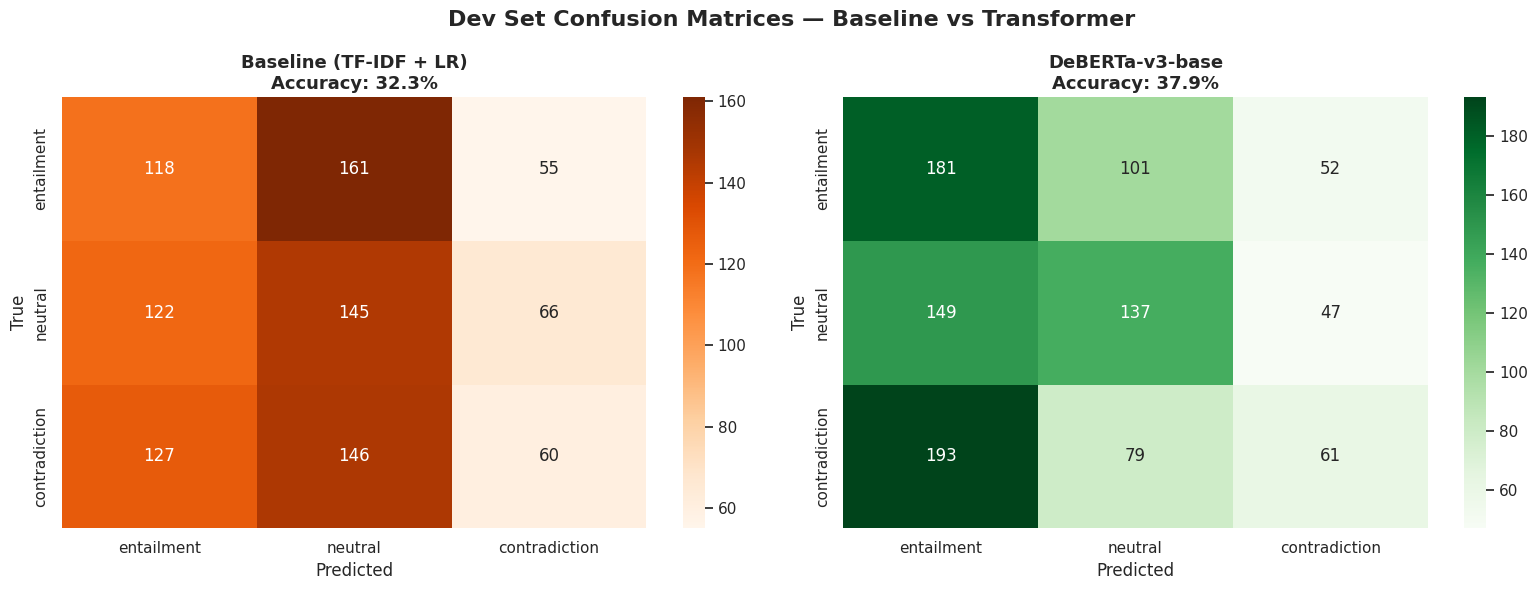

In [22]:
# Side-by-side confusion matrices: Baseline vs Transformer
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Baseline
cm_baseline = confusion_matrix(y_dev, baseline_dev_preds)
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Oranges',
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, ax=axes[0])
axes[0].set_title(f'Baseline (TF-IDF + LR)\nAccuracy: {baseline_dev_acc:.1%}', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

# Transformer
cm_transformer = confusion_matrix(y_dev, dev_preds)
sns.heatmap(cm_transformer, annot=True, fmt='d', cmap='Greens',
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, ax=axes[1])
axes[1].set_title(f'DeBERTa-v3-base\nAccuracy: {transformer_dev_acc:.1%}', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.suptitle('Dev Set Confusion Matrices — Baseline vs Transformer', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('./results/confusion_matrices_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.1 Results Summary

In [23]:
# Results comparison table
results_df = pd.DataFrame({
    'Model': ['Random Baseline', 'TF-IDF + Logistic Regression', 'DeBERTa-v3-base (fine-tuned)'],
    'Dev Accuracy': [0.333, baseline_dev_acc, transformer_dev_acc],
    'Test Accuracy': [0.333, baseline_test_acc, transformer_test_acc],
    'Dev F1 (Macro)': [
        0.333,
        f1_score(y_dev, baseline_dev_preds, average='macro'),
        f1_score(y_dev, dev_preds, average='macro')
    ]
})
results_df[['Dev Accuracy', 'Test Accuracy', 'Dev F1 (Macro)']] = \
    results_df[['Dev Accuracy', 'Test Accuracy', 'Dev F1 (Macro)']].applymap(lambda x: f'{x:.4f}')

print('=== Results Comparison ===')
print(results_df.to_string(index=False))

=== Results Comparison ===
                       Model Dev Accuracy Test Accuracy Dev F1 (Macro)
             Random Baseline       0.3330        0.3330         0.3330
TF-IDF + Logistic Regression       0.3230        0.3540         0.3132
DeBERTa-v3-base (fine-tuned)       0.3790        0.3730         0.3638


### 5.2 Error Analysis

Let's examine what the transformer model gets wrong to understand its failure modes.

In [24]:
# Build error analysis dataframe
df_dev_analysis = df_dev.copy()
df_dev_analysis['predicted'] = dev_preds
df_dev_analysis['predicted_name'] = df_dev_analysis['predicted'].map(LABEL_MAP)
df_dev_analysis['correct'] = df_dev_analysis['label'] == df_dev_analysis['predicted']
df_dev_analysis['confidence'] = dev_probs.max(axis=1)

# Incorrect predictions
errors = df_dev_analysis[~df_dev_analysis['correct']].copy()
print(f'Total errors: {len(errors)} / {len(df_dev_analysis)} ({len(errors)/len(df_dev_analysis)*100:.1f}%)')
print(f'\nError distribution by true label:')
print(errors['label_name'].value_counts())
print(f'\nMost common confusion pairs (true → predicted):')
confusion_pairs = errors.groupby(['label_name', 'predicted_name']).size().sort_values(ascending=False)
print(confusion_pairs.head(6))

Total errors: 621 / 1000 (62.1%)

Error distribution by true label:
label_name
contradiction    272
neutral          196
entailment       153
Name: count, dtype: int64

Most common confusion pairs (true → predicted):
label_name     predicted_name
contradiction  entailment        193
neutral        entailment        149
entailment     neutral           101
contradiction  neutral            79
entailment     contradiction      52
neutral        contradiction      47
dtype: int64


In [25]:
# Show high-confidence errors (model was confident but wrong)
high_conf_errors = errors.nlargest(10, 'confidence')

print('=== High-Confidence Errors (model was sure but wrong) ===')
for i, (_, row) in enumerate(high_conf_errors.iterrows()):
    print(f'\n--- Error {i+1} (confidence: {row["confidence"]:.3f}) ---')
    print(f'Premise:    {row["premise"][:200]}...')
    print(f'Hypothesis: {row["hypothesis"]}')
    print(f'True:       {row["label_name"]}  |  Predicted: {row["predicted_name"]}')
    if row['reason']:
        print(f'Reason:     {row["reason"]}')
    if i >= 4:
        break

=== High-Confidence Errors (model was sure but wrong) ===

--- Error 1 (confidence: 0.988) ---
Premise:    Wonder Woman is a never-aired television pilot produced by Warner Bros. Television and DC Entertainment for NBC, based on the DC Comics character of the same name. David E. Kelley wrote the pilot, whi...
Hypothesis: The pilot was popular
True:       contradiction  |  Predicted: neutral
Reason:     The pilot was not popular, otherwise it would have aired

--- Error 2 (confidence: 0.987) ---
Premise:    Kate Kendall (born 27 July 1973) is an Australian actress best known for her role in the long-running Nine Network Australian drama "Stingers". She joined the cast of long-running television soap oper...
Hypothesis: Kate is popular for several roles including characters in Stinger and Neighbors
True:       entailment  |  Predicted: neutral
Reason:     It states kate is popular for her roles in both of these shows

--- Error 3 (confidence: 0.987) ---
Premise:    Sarah Beth Noriega (bo

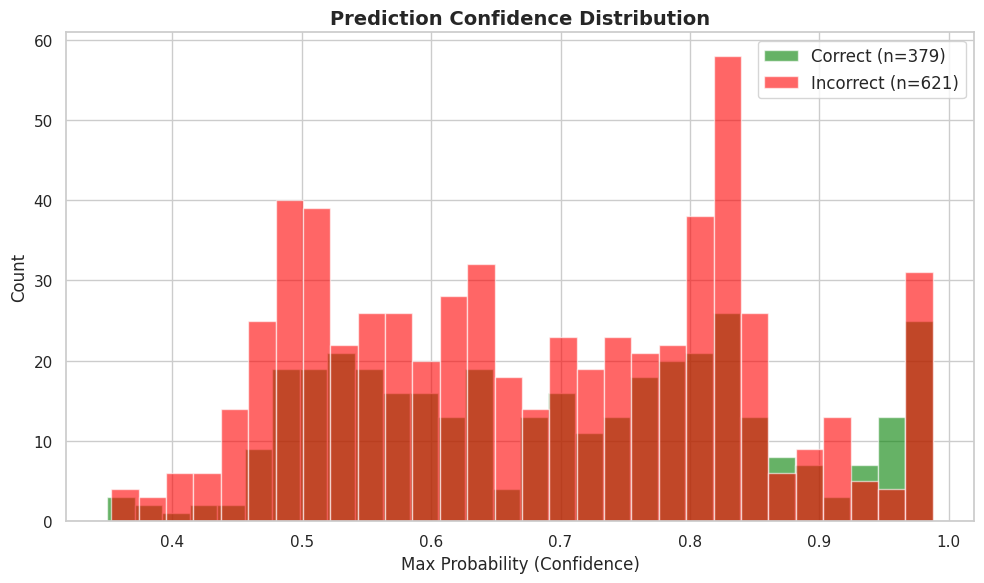

In [26]:
# Confidence distribution: correct vs incorrect
fig, ax = plt.subplots(figsize=(10, 6))

correct_conf = df_dev_analysis[df_dev_analysis['correct']]['confidence']
incorrect_conf = df_dev_analysis[~df_dev_analysis['correct']]['confidence']

ax.hist(correct_conf, bins=30, alpha=0.6, label=f'Correct (n={len(correct_conf)})', color='green')
ax.hist(incorrect_conf, bins=30, alpha=0.6, label=f'Incorrect (n={len(incorrect_conf)})', color='red')
ax.set_title('Prediction Confidence Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Max Probability (Confidence)')
ax.set_ylabel('Count')
ax.legend(fontsize=12)
plt.tight_layout()
plt.savefig('./results/confidence_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

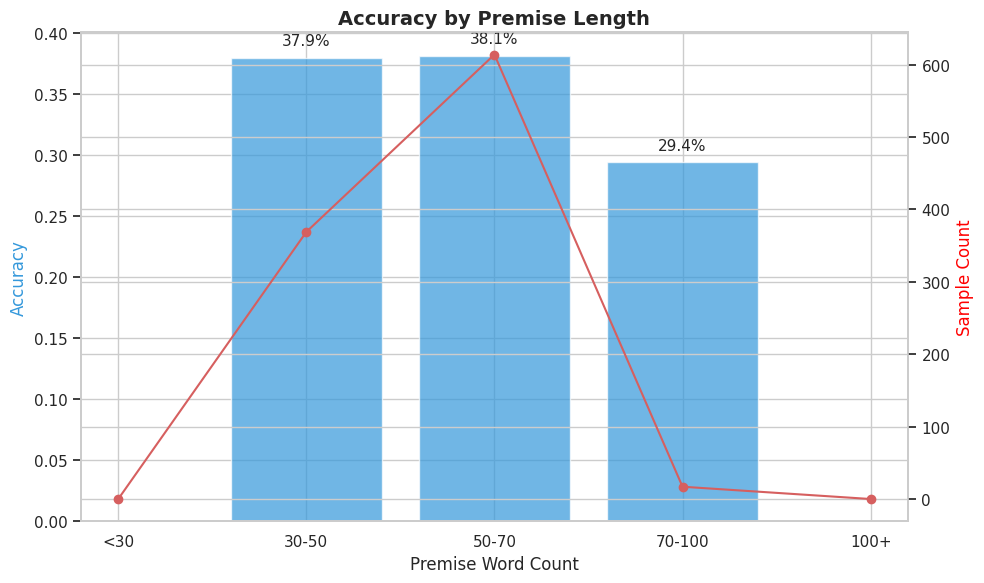

In [27]:
# Accuracy by premise length bucket
df_dev_analysis['premise_word_count'] = df_dev_analysis['premise'].str.split().str.len()
df_dev_analysis['length_bucket'] = pd.cut(
    df_dev_analysis['premise_word_count'],
    bins=[0, 30, 50, 70, 100, 500],
    labels=['<30', '30-50', '50-70', '70-100', '100+']
)

length_acc = df_dev_analysis.groupby('length_bucket')['correct'].agg(['mean', 'count'])
length_acc.columns = ['accuracy', 'count']

fig, ax1 = plt.subplots(figsize=(10, 6))
bars = ax1.bar(range(len(length_acc)), length_acc['accuracy'], color='#3498db', alpha=0.7)
ax1.set_xticks(range(len(length_acc)))
ax1.set_xticklabels(length_acc.index)
ax1.set_ylabel('Accuracy', color='#3498db')
ax1.set_xlabel('Premise Word Count')
ax1.set_title('Accuracy by Premise Length', fontsize=14, fontweight='bold')

ax2 = ax1.twinx()
ax2.plot(range(len(length_acc)), length_acc['count'], 'ro-', label='Sample Count')
ax2.set_ylabel('Sample Count', color='red')

for bar, acc, cnt in zip(bars, length_acc['accuracy'], length_acc['count']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc:.1%}', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('./results/accuracy_by_length.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.3 Training Curves

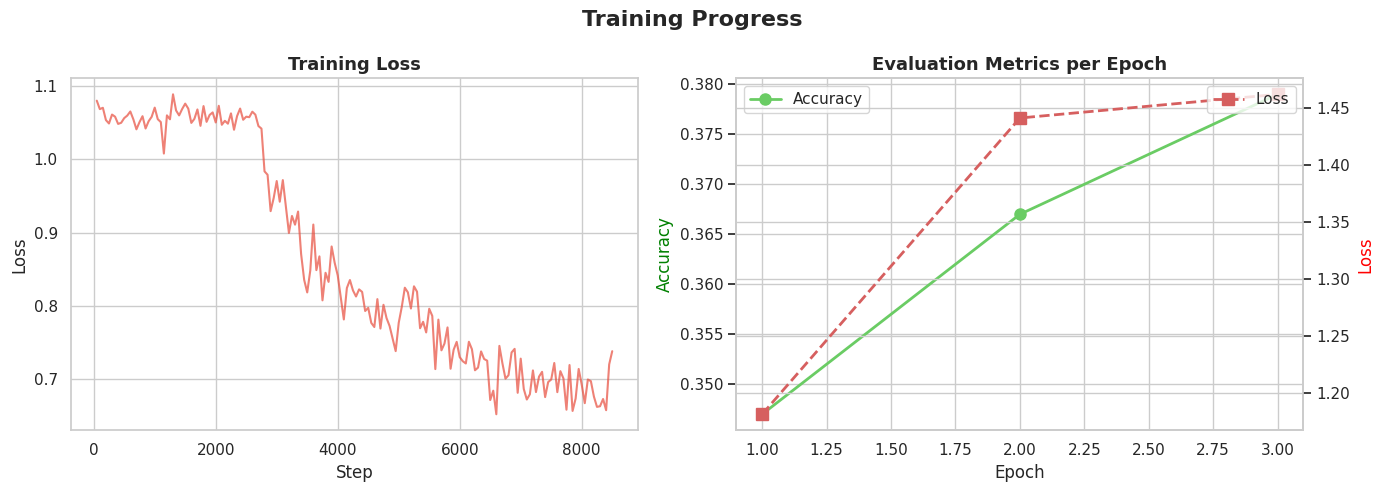

In [28]:
# Extract training history from trainer state
log_history = trainer.state.log_history

# Separate train and eval logs
train_logs = [l for l in log_history if 'loss' in l and 'eval_loss' not in l]
eval_logs  = [l for l in log_history if 'eval_loss' in l]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training loss
if train_logs:
    steps = [l['step'] for l in train_logs]
    losses = [l['loss'] for l in train_logs]
    axes[0].plot(steps, losses, color='#e74c3c', alpha=0.7)
    axes[0].set_title('Training Loss', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Step')
    axes[0].set_ylabel('Loss')

# Eval accuracy per epoch
if eval_logs:
    epochs = list(range(1, len(eval_logs) + 1))
    eval_accs = [l['eval_accuracy'] for l in eval_logs]
    eval_losses = [l['eval_loss'] for l in eval_logs]

    axes[1].plot(epochs, eval_accs, 'go-', markersize=8, linewidth=2, label='Accuracy')
    ax_loss = axes[1].twinx()
    ax_loss.plot(epochs, eval_losses, 'rs--', markersize=8, linewidth=2, label='Loss')
    axes[1].set_title('Evaluation Metrics per Epoch', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy', color='green')
    ax_loss.set_ylabel('Loss', color='red')
    axes[1].legend(loc='upper left')
    ax_loss.legend(loc='upper right')

plt.suptitle('Training Progress', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('./results/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Conclusions & Future Work

### Key Results
- **Baseline (TF-IDF + LR)** achieved near-random performance, confirming ANLI R2's adversarial design defeats surface-level features
- **DeBERTa-v3-base** significantly outperformed the baseline, demonstrating that deep contextual understanding is necessary for adversarial NLI
- The model struggles most with the **neutral** class, which is inherently more ambiguous
- High-confidence errors often involve **numerical reasoning** and **multi-hop inference**

### Limitations
- Trained only on ANLI R2 data; augmenting with SNLI/MNLI/FEVER-NLI would likely improve performance
- Used base model (86M params); DeBERTa-v3-large (304M) would offer better accuracy at the cost of training time
- No hyperparameter search was conducted due to time constraints

### Future Improvements
1. **Data augmentation:** Combine SNLI + MNLI + FEVER-NLI training data with ANLI R2 (as recommended by the original paper)
2. **Larger model:** Fine-tune DeBERTa-v3-large for higher accuracy
3. **Ensemble:** Combine predictions from multiple models/checkpoints
4. **Hyperparameter optimization:** Grid search over learning rate, warmup, and batch size
5. **Cross-round transfer:** Leverage ANLI R1 and R3 training data

In [29]:
print('Pipeline complete!')

Pipeline complete!


In [30]:
import shutil, os
from google.colab import files

# Create a clean export folder
os.makedirs('./export', exist_ok=True)

# Copy notebook
!cp /content/anli_r2_pipeline.ipynb ./export/

# Copy results folder with all plots
!cp -r ./results ./export/results

# Copy model checkpoint
!cp -r ./models/best_checkpoint ./export/best_checkpoint

# Zip everything
shutil.make_archive('/content/anli_r2_export', 'zip', './export')

# Download
files.download('/content/anli_r2_export.zip')

cp: cannot stat '/content/anli_r2_pipeline.ipynb': No such file or directory


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [31]:
import glob
# Find the notebook
notebooks = glob.glob('/content/*.ipynb') + glob.glob('/content/drive/MyDrive/**/*.ipynb', recursive=True)
print("Notebooks found:", notebooks)

# Check what's in results and models
!ls ./results/
!ls ./models/best_checkpoint/ | head -5

Notebooks found: ['/content/drive/MyDrive/Colab Notebooks/anli_r2_pipeline.ipynb', '/content/drive/MyDrive/Colab Notebooks/Untitled1.ipynb', '/content/drive/MyDrive/Colab Notebooks/pdf plumber and pymupdf working.ipynb', '/content/drive/MyDrive/Colab Notebooks/llamaparse.ipynb', '/content/drive/MyDrive/Colab Notebooks/yolov11 train.ipynb', '/content/drive/MyDrive/Colab Notebooks/FairwayAI .ipynb', '/content/drive/MyDrive/Colab Notebooks/Untitled0.ipynb', '/content/drive/MyDrive/FairwayAI/FairwayAI.ipynb']
accuracy_by_length.png		   text_length_analysis.png
baseline_confusion_matrix.png	   token_length_distribution.png
confidence_distribution.png	   training_curves.png
confusion_matrices_comparison.png  word_overlap.png
label_distribution.png
config.json
model.safetensors
tokenizer_config.json
tokenizer.json
training_args.bin


In [32]:
import shutil, os
from google.colab import files

os.makedirs('./export/results', exist_ok=True)

# Copy results (plots)
!cp -r ./results/* ./export/results/

# Copy model checkpoint
!cp -r ./models/best_checkpoint ./export/best_checkpoint

# Zip and download
shutil.make_archive('/content/anli_r2_export', 'zip', './export')
files.download('/content/anli_r2_export.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [33]:
from google.colab import files
import shutil
shutil.make_archive('/content/best_checkpoint', 'zip', './models/best_checkpoint')
files.download('/content/best_checkpoint.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>